In [13]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
pfns = PlottingFns()

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND


In [16]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation

In [17]:


def get_geostrophic_currents(eta):
    lat_name = 'latitude'
    lon_name = 'longitude'
    g = 9.81
    R = 6371000.0
    omega = 7.292115e-5

    # Ensure coords are present and in degrees
    lat = eta.coords[lat_name]
    lon = eta.coords[lon_name]

    # radians
    lat_r = np.deg2rad(lat)
    lon_r = np.deg2rad(lon)

    # Build helper to take gradients along given axes using the 1D radian coords
    # Works for data with optional leading dims (e.g., time)
    def d_dcoord(da: xr.DataArray, coord: xr.DataArray, axis: int) -> xr.DataArray:
        arr = da.data
        coord_vals = coord.data
        grad = np.gradient(arr, coord_vals, axis=axis, edge_order=2)
        return xr.zeros_like(da) + grad  # keep xarray wrapper/dims

    # Axis indices for lat/lon (support datasets with extra leading dims)
    lat_axis = eta.get_axis_num(lat_name)
    lon_axis = eta.get_axis_num(lon_name)

    # Partial derivatives wrt latitude/longitude in *radians*
    deta_dphi   = d_dcoord(eta, lat_r, lat_axis)         # ∂η/∂φ
    deta_dlambda= d_dcoord(eta, lon_r, lon_axis)         # ∂η/∂λ

    # Coriolis parameter f(φ)
    f = np.sin(lat_r) * omega * 2

    # Broadcast f and cosφ to data shape
    # (xarray auto-broadcasts by coords when wrapped in DataArray with dims)
    f_da = xr.DataArray(f, dims=(lat_name,), coords={lat_name: lat})
    cosphi = xr.DataArray(np.cos(lat_r), dims=(lat_name,), coords={lat_name: lat})

    # Geostrophic components
    ug = (1.0 / R) * deta_dphi * -(g / f_da) 
    vg = (1.0 / (R * cosphi)) * deta_dlambda * (g / f_da)

    ug.name = "ug"; ug.attrs.update(units="m s-1", long_name="zonal geostrophic velocity")
    vg.name = "vg"; vg.attrs.update(units="m s-1", long_name="meridional geostrophic velocity")

    return ug, vg




In [18]:
sla_ = SLA(deg=0.25).da
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
dotds = DOT().ds.rename({'ug':'u10','vg':'v10'})

In [7]:
extent_ac = [138,152,-68,-63]
extent_gyre = [145,150,-66.5,-65.5]
extent_ea = [60,160,-70,-60]
elevation = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

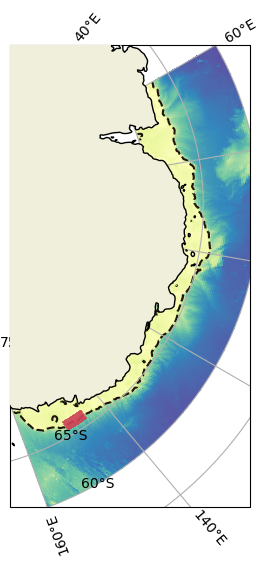

In [8]:
# show study area and gyre area
region_ac = Region('AC',extent_ac)
region_gyre = Region('Gyre',extent_gyre,elevation=elevation)
region_gyre.plot_region(da=elevation,extent=extent_ea)

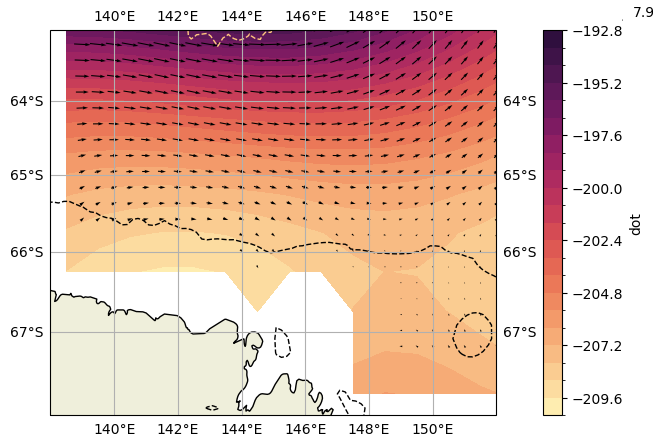

In [9]:
# show mdt an mean geostrophic currents
dot = region_ac.crop_da(dotds)
mdt = dot.mean('time')

fig,ax = plt.subplots(figsize=(12,5),subplot_kw={'projection':ccrs.Mercator()})
mdt.dot.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.matter,transform=ccrs.PlateCarree(),levels=25)
mdt.plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=25)

elevation.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

In [10]:
region = Region('Adelie',extent_ac,elevation=elevation)#,min_elevation=-1000)
sla = region.crop_da(sla_)
sice = region.crop_da(sice_)
winds = region.crop_da(winds_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

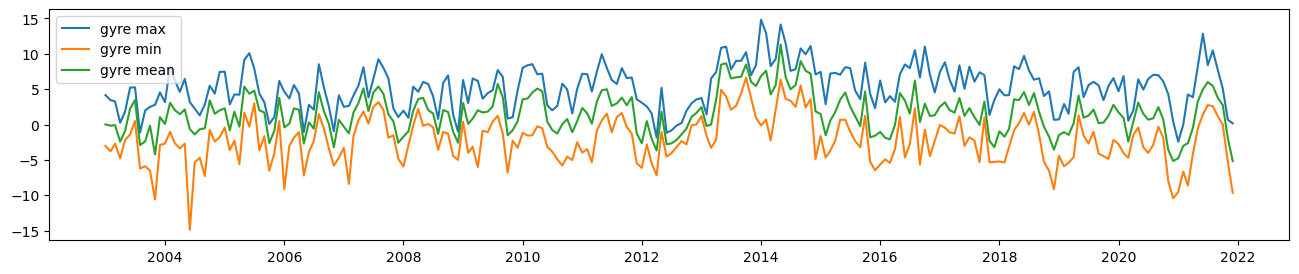

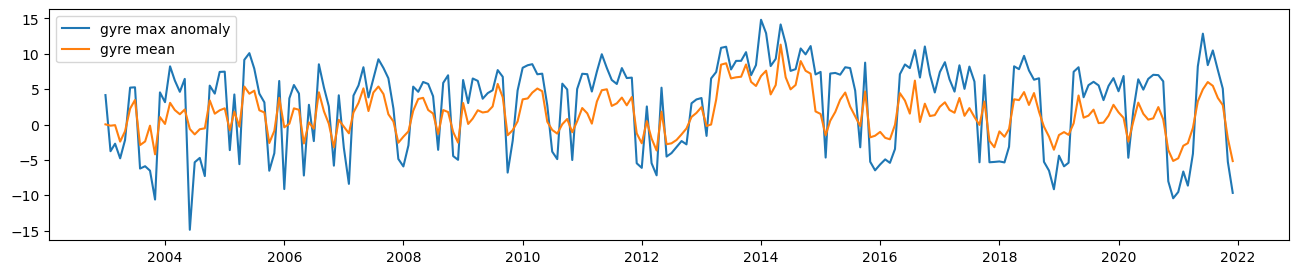

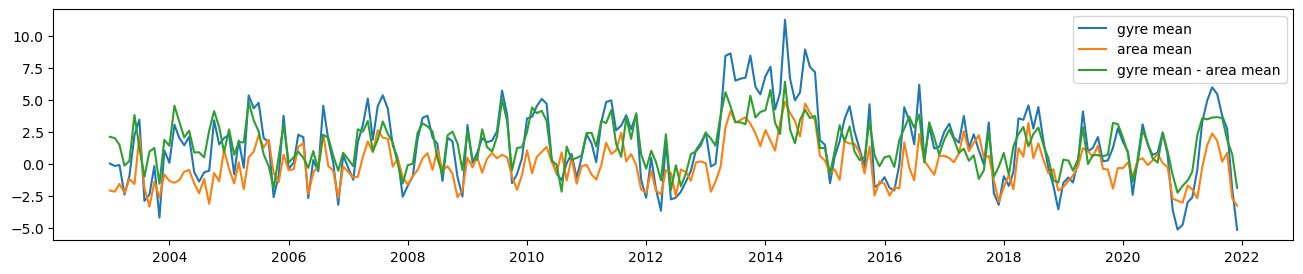

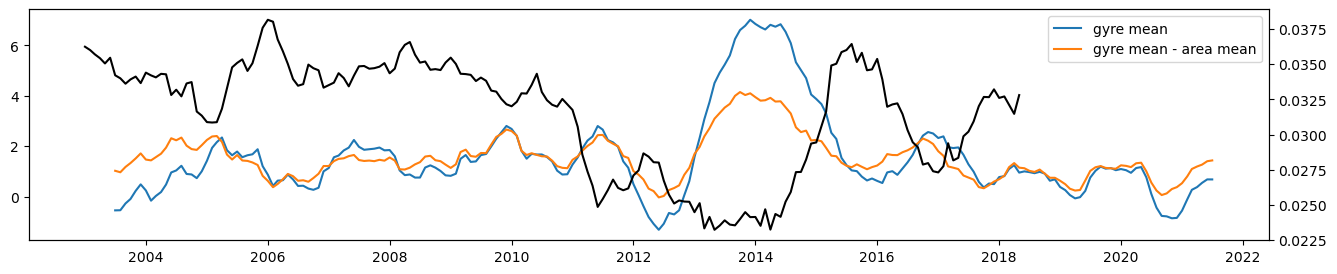

In [11]:
sla_gyre = region_gyre.crop_da(sla_)

ll = ['latitude','longitude']
ghmax = sla_gyre.max(ll)
ghmin = sla_gyre.min(ll)
ghmean = sla_gyre.mean(ll)

gyre_max_anom = [gh.max(ll) if gh.mean(ll) > 0 else gh.min(ll) for gh in sla_gyre]
gyre_index = ghmean - sla.mean(ll)

# compare different gyre indices
fig,ax = plt.subplots(figsize=(16,3))
ax.plot(sla_gyre.time,ghmax,label='gyre max')
ax.plot(sla_gyre.time,ghmin,label='gyre min')
ax.plot(sla_gyre.time,ghmean,label='gyre mean')
ax.legend()

# compare different gyre indices
fig,ax = plt.subplots(figsize=(16,3))
ax.plot(sla_gyre.time,gyre_max_anom,label='gyre max anomaly')
ax.plot(sla_gyre.time,ghmean,label='gyre mean')
ax.legend()

# compare different gyre indices
fig,ax = plt.subplots(figsize=(16,3))
ax.plot(sla_gyre.time,ghmean,label='gyre mean')
ax.plot(sla.time,sla.mean(ll),label='area mean')
ax.plot(sla_gyre.time,gyre_index,label='gyre mean - area mean')
ax.legend()

fig,ax = plt.subplots(figsize=(16,3))


# compare with ASC
ax.plot(sla_gyre.time,ghmean.rolling({'time':12},center=True).mean(),label='gyre mean')
ax.plot(sla_gyre.time,gyre_index.rolling({'time':12},center=True).mean(),label='gyre mean - area mean')

#compute asc strength
asc=dotds.u10.sel(latitude=slice(-65,-64)).sel(longitude=145,method='nearest').mean('latitude')
ax.twinx().plot(asc.time,asc.rolling({'time':12},center=True).mean(),c='k')

ax.legend()

In [ ]:
#plos min and maxes
# fig,ax = plt.subplots(1,2,figsize=(16,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
# t=pd.Timestamp(2014,1,1)
# plotc(ax[0],sla.sel(time=t),'max ={}, min={}'.format(ghmax.sel(time=t).item(),ghmin.sel(time=t).item()),extent,cmap=cmocean.cm.balance)
#plotc(ax[1],season_split(sice)['winter'].mean('time'),'SIC WINTER',extent,vmin=0.4,vmax=1,cmap=cmocean.cm.ice)

In [12]:
# export index
gyre_index.to_netcdf('gyre_index.nc')